In [8]:
import numpy as np
import pandas as pd
import os
import joblib
import pickle
import math
import ast
from scipy.stats import median_abs_deviation, hypergeom, mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

In [9]:
import sys
# Ensure this analysis directory is importable regardless of kernel CWD
_here = '/projects/bhdw/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/analysis'
if _here not in sys.path:
    sys.path.insert(0, _here)

import dictys
from utils_custom import *
from pseudotime_curves import *
from episodic_dynamics import *
from config import *

In [10]:
import importlib
import firefate.utils.plots, firefate.utils.custom
import temporal_clustering
# reload firefate helpers first, then temporal_clustering so it re-binds fresh names
importlib.reload(firefate.utils.plots)
importlib.reload(firefate.utils.custom)
importlib.reload(temporal_clustering)
from temporal_clustering import StateFrequency, TFForceWaves, TFForceValidation

In [11]:
config = Config()

In [12]:
# Load data
dictys_dynamic_object = dictys.net.dynamic_network.from_file('/work/nvme/bhdw/asachan/data_files/firefate/bcell/outs/dynamic.h5')

### Defining lineage trajectories

In [13]:
PB_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2]
GC_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3]
PB_post_bifurcation_window_indices = [0] + list(range(98, 147, 1)) + [2]
GC_post_bifurcation_window_indices = [0] + list(range(147, 193, 1)) + [3]

In [14]:
# Define distinct colors for better visibility
colors_cell_count = {
    'ActB-1': '#87CEFA',     # lightskyblue
    'ActB-2': '#1E90FF',     # dodgerblue
    'ActB-3': '#00008B',     # darkblue
    'ActB-4': '#9370DB',     # mediumorchid
    'GC-1': '#7BDE7B',       # custom light green
    'GC-2': '#008000',       # green
    'PB-2': '#BB3636',       # custom red
    'earlyActB': '#008080',   # teal
    'earlyPB': '#F08080'   # lightcoral
}

## TF forces per branch

In [16]:
# Class 2: TF forces over pseudotime (expression / regulation curves cached internally)
waves_pb = TFForceWaves(
    dictys_dynamic_object,
    trajectory_range=(0, 2),
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
)

In [17]:
# GC branch: same TF-forces machinery over the GC trajectory (node 0 -> 3).
waves_gc = TFForceWaves(
    dictys_dynamic_object,
    trajectory_range=(0, 3),
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
)

### FIREFate state-specific enriched links

In [18]:
ss_firefate_combined = pd.read_csv('/projects/bhdw/asachan/tmp/ss_firefate_links_2B.csv')

In [19]:
display(ss_firefate_combined)

,source,target,key,weight,cluster,strength,case
0,PRDM1,RUNX2,1,0.293075,3,1,slide
1,PRDM1,IQGAP2,1,0.219831,3,1,slide
2,BACH2,XBP1,0,-0.229950,7,1,slide
3,BACH2,MZB1,1,-0.234813,3,1,slide
4,BACH2,JCHAIN,1,-0.258168,3,1,slide
...,...,...,...,...,...,...,...
73,PBX3,CDK6,1,0.231756,3,1,slide
74,PBX3,AFF3,1,0.332018,3,1,slide
75,ARID5B,CPEB4,1,0.237878,3,1,slide
76,ARID5B,PDE4D,0,0.228636,7,1,slide


In [20]:
# Build (TF, target) tuples, keeping only links whose TF and target are both
# present in the dictys object. get_beta_curves can only compute forces for genes
# in the GRN (TFs in nids[0], targets in ndict); filtering here makes the computed
# link set explicit rather than relying on the internal skip.
all_links = list(zip(ss_firefate_combined['source'], ss_firefate_combined['target']))

_, _, missing_tfs = get_tf_indices(dictys_dynamic_object, list({tf for tf, _ in all_links}))
missing_tfs = set(missing_tfs)
ndict = dictys_dynamic_object.ndict

ss_firefate_combined_tuple = [(tf, tg) for tf, tg in all_links
                     if tf not in missing_tfs and tg in ndict]
dropped = [(tf, tg) for tf, tg in all_links
           if tf in missing_tfs or tg not in ndict]
print(f"{len(ss_firefate_combined_tuple)}/{len(all_links)} links kept; "
      f"{len(dropped)} dropped (TF/target absent from GRN): {dropped}")

66/78 links kept; 12 dropped (TF/target absent from GRN): [('AFF1', 'MAN1A1'), ('AFF1', 'FNDC3A'), ('AFF1', 'CEP128'), ('HERPUD1', 'TRAM1'), ('HERPUD1', 'IRF4'), ('HERPUD1', 'BTG2'), ('HERPUD1', 'PAX5'), ('HIVEP2', 'IRF4'), ('HIVEP2', 'BTG2'), ('HIVEP2', 'GAB1'), ('HIVEP2', 'GLCCI1'), ('HIVEP2', 'CPEB4')]


In [21]:
# Compute beta / TF-expression / force curves for the prioritized links (PB branch)
force_curves_pb = waves_pb.compute_forces(ss_firefate_combined_tuple, varname='w_in')

In [22]:
# Compute force curves for the same prioritized links on the GC branch.
force_curves_gc = waves_gc.compute_forces(ss_firefate_combined_tuple, varname='w_in')

## Cross-branch pooled comparison (PB ∪ GC)

,link,group,branch,abs_max_force
0,"(PRDM1, RUNX2)",enriched,PB,0.478067
1,"(CREB3L2, XBP1)",enriched,PB,0.345994
2,"(CREB3L2, GAB1)",enriched,PB,0.392802
3,"(CREB3L2, SEL1L3)",enriched,PB,0.380081
4,"(CREB3L2, TXNDC5)",enriched,GC,0.819643
...,...,...,...,...
127,"(ZNF18, RACGAP1)",random,PB,0.155172
128,"(TCFL5, METTL18)",random,PB,0.120712
129,"(ZNF18, NARF)",random,PB,0.252787
130,"(ATF2, IMPG2)",random,PB,0.225295


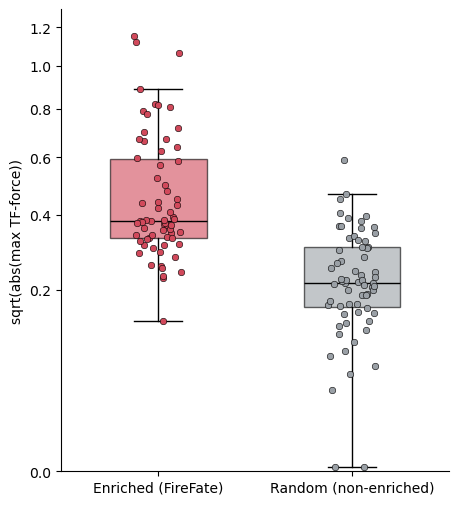

In [23]:
# The 66 enriched links act on both the PB and GC branches, so collapsing a single
# branch across phases under-separates them. Score each enriched link on BOTH branches
# and keep its abs-max TF force across branches; the random null is the UNION of the
# per-branch random pools (each random link keeps its own single-branch force, not a
# cross-branch max), size-matched to the enriched links. The result keeps a
# 'branch' column = the lineage where each enriched link's force was strongest.
def _fwd(x):
    return np.sqrt(np.clip(x, 0, None))
def _inv(x):
    return np.square(x)

xval = TFForceValidation(
    {'PB': waves_pb, 'GC': waves_gc},
    enriched_links=ss_firefate_combined_tuple,
    varname='w_in',
    mode='combined',
)
xval_df = xval.run(exclude='tf_and_target', random_state=0)
display(xval_df)

fig, ax = xval.plot(ylabel='sqrt(abs(max TF-force))')
ax.set_yscale("function", functions=(_fwd, _inv))
ax.set_ylim(0, 1.3)   # explicit, non-negative floor — don't let it auto-pad below 0
# save as svg with editable text
#fig.savefig('/projects/bhdw/asachan/papers/firefate/figures/state_specific_links_validation.svg', format='svg', bbox_inches='tight')
plt.show()

### State-constrained random null (PB-2 / GC-1 windows)

The cross-branch null above samples random links from the whole TF × target universe.
Here the null is *constrained* to the cell-states the 66 enriched links were derived
from: random links are sampled only from edges **present** (direct-effect
`prop['es']['w'] != 0`) in windows whose **combined PB-2 + GC-1 composition > 50%**,
after removing every enriched TF and target node (the "not-of-nodes"). Links are
sampled first; their TF force is computed *post hoc* and scored as abs-max across both
branches — exactly how the enriched links were selected. The state constraint should
pull the random forces up (those nodes are state-related), shrinking — but, if the
enriched *links* carry signal beyond their nodes, not closing — the gap.

,link,group,branch,abs_max_force
0,"(PRDM1, RUNX2)",enriched,PB,0.478067
1,"(CREB3L2, XBP1)",enriched,PB,0.345994
2,"(CREB3L2, GAB1)",enriched,PB,0.392802
3,"(CREB3L2, SEL1L3)",enriched,PB,0.380081
4,"(CREB3L2, TXNDC5)",enriched,GC,0.819643
...,...,...,...,...
127,"(ZFY, CHRM5)",random,PB,0.246515
128,"(E2F6, BLM)",random,PB,0.408613
129,"(ZNF425, PFDN1)",random,PB,0.280465
130,"(KLF16, VKORC1L1)",random,GC,0.361966


MannwhitneyuResult(statistic=np.float64(2561.0), pvalue=np.float64(0.040858116145159946))


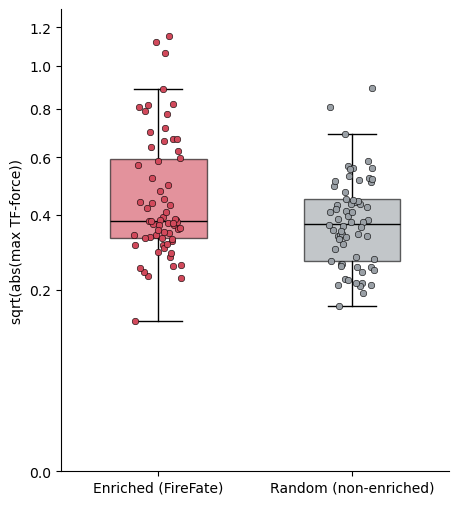

In [24]:
# Constrained null: sample random links only from edges present in windows dominated
# (>50% combined composition) by the PB-2 / GC-1 states the enriched links came from,
# with all enriched TF/target nodes removed. Reuses xval (same selector + cached
# enriched forces); both groups scored as abs-max TF force across both branches.
xval_constrained_df = xval.run_constrained(
    config.CELL_LABELS, states=('PB-2', 'GC-1'), threshold=0.5, random_state=0)
display(xval_constrained_df)

print(mannwhitneyu(
    xval_constrained_df.loc[xval_constrained_df['group'] == 'enriched', 'abs_max_force'],
    xval_constrained_df.loc[xval_constrained_df['group'] == 'random', 'abs_max_force'],
    alternative='greater'))

fig, ax = xval.plot(ylabel='sqrt(abs(max TF-force))')
ax.set_yscale("function", functions=(_fwd, _inv))
ax.set_ylim(0, 1.3)   # explicit, non-negative floor — don't let it auto-pad below 0
#fig.savefig('/projects/bhdw/asachan/papers/firefate/figures/state_specific_links_validation_constrained_null.svg',
#            format='svg', bbox_inches='tight')
plt.show()

# Validation of episodic links